<a href="https://colab.research.google.com/github/sabrynkhatr696-design/Image-Classification-Using-CNN/blob/main/student_productivity_dbscan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#"تحليل أنماط أداء الطلاب في مادة الرياضيات باستخدام خوارزمية DBSCAN

# Student Productivity Analysis using DBSCAN

This project analyzes student productivity patterns using the DBSCAN clustering algorithm.

The goal is to identify groups of students based on their study habits, focus levels, and productivity scores.

## Dataset Features
- study_hours
- self_study_hours
- focus_index
- burnout_level
- productivity_score
- gender
- academic_level
- internet_quality

## Methodology
1. Data Exploration
2. Data Preprocessing
3. Feature Scaling
4. DBSCAN Clustering
5. Cluster Analysis
6. Visualization

## Technologies Used
- Python
- Pandas
- NumPy
- Scikit-learn
- Matplotlib

In [ ]:
import numpy as np
import pandas as pd
df = pd.read_csv('student_productivity.csv')
df.head()

,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
0,1,18,Other,High School,7.64,1.56,2.20,3.05,2.19,6.52,...,81,38,1,0,Good,10,43.05,31.77,73.65,50.16
1,2,18,Other,High School,2.21,2.22,2.10,1.65,2.55,5.97,...,111,339,0,0,Good,3,15.92,37.00,13.70,1.00
2,3,22,Male,High School,3.45,0.00,0.29,1.34,2.08,8.39,...,68,266,0,1,Good,8,27.39,34.37,45.15,18.30
3,4,17,Other,High School,5.75,2.08,3.01,2.27,2.20,6.31,...,113,480,1,1,Poor,3,22.31,77.31,20.92,9.37
4,5,19,Other,High School,6.83,1.72,3.33,2.65,0.70,8.01,...,121,24,1,0,Good,8,38.11,39.53,59.23,27.81


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            5000 non-null   int64  
 1   age                   5000 non-null   int64  
 2   gender                5000 non-null   object 
 3   academic_level        5000 non-null   object 
 4   study_hours           5000 non-null   float64
 5   self_study_hours      5000 non-null   float64
 6   online_classes_hours  5000 non-null   float64
 7   social_media_hours    5000 non-null   float64
 8   gaming_hours          5000 non-null   float64
 9   sleep_hours           5000 non-null   float64
 10  screen_time_hours     5000 non-null   float64
 11  exercise_minutes      5000 non-null   int64  
 12  caffeine_intake_mg    5000 non-null   int64  
 13  part_time_job         5000 non-null   int64  
 14  upcoming_deadline     5000 non-null   int64  
 15  internet_quality     

In [ ]:
# df.isnull().sum() # لا يوجد Missing Values

In [ ]:
# df.duplicated().sum() #ما فيه صفوف مكررة


In [ ]:
num_cols = df.select_dtypes(include='number').columns
cat_cols = df.select_dtypes(include='object').columns
#

In [ ]:
cat_cols

Index(['gender', 'academic_level', 'internet_quality'], dtype='object')

In [ ]:
#Encoder
from sklearn.preprocessing import LabelEncoder
for col in ['gender','academic_level','internet_quality']:
    df[col] = LabelEncoder().fit_transform(df[col])

  ### الأعمدة المرتبطة بالأداء الأكاديمي
  study_hours, self_study_hours, focus_index, burnout_level, productivity_score ,exam_score

In [ ]:
# توحيد المقياس (Scaling):
#StandardScaler
from sklearn.preprocessing import StandardScaler
X = df[['study_hours','self_study_hours','focus_index','burnout_level','productivity_score','exam_score']]
X_scaled = StandardScaler().fit_transform(X)

In [ ]:
from sklearn.metrics import silhouette_score

for eps in [0.5, 1.0, 1.5, 2.0]:
    for min_samples in [5, 10, 20]:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_scaled)

        # نتأكد فيه أكثر من Cluster
        if len(set(labels)) > 1:
            score = silhouette_score(X_scaled, labels)
            print(f"eps={eps}, min_samples={min_samples}, Silhouette={score:.3f}")

eps=0.5, min_samples=5, Silhouette=-0.502
eps=0.5, min_samples=10, Silhouette=-0.434
eps=1.0, min_samples=5, Silhouette=0.308
eps=1.0, min_samples=10, Silhouette=0.297
eps=1.0, min_samples=20, Silhouette=0.264
eps=1.5, min_samples=5, Silhouette=0.451
eps=1.5, min_samples=10, Silhouette=0.451
eps=1.5, min_samples=20, Silhouette=0.432
eps=2.0, min_samples=10, Silhouette=0.549
eps=2.0, min_samples=20, Silhouette=0.549


In [ ]:
from sklearn.cluster import DBSCAN

# نحدد باراميترات DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=10)

# نطبق الخوارزمية
labels = dbscan.fit_predict(X_scaled)

# نضيف النتائج للداتا الأصلية
df['Cluster'] = labels

In [ ]:
df['Cluster'].value_counts()

,count
Cluster,
0,4996
-1,4


In [ ]:
#- تحليل خصائص كل Cluster:
cluster_summary = df.groupby('Cluster')[['study_hours','self_study_hours','focus_index','burnout_level','productivity_score','exam_score']].mean()
print(cluster_summary)

         study_hours  self_study_hours  focus_index  burnout_level  \
Cluster                                                              
-1          8.722500          3.805000    46.147500      51.760000   
 0          4.536245          2.477672    29.418233      45.610404   

         productivity_score  exam_score  
Cluster                                  
-1                69.697500   41.317500  
 0                37.241751   18.785727  


In [ ]:
# حذف الطلاب اللي DBSCAN صنفهم كـ Outliers (Cluster = -1)
df_no_outliers = df[df['Cluster'] != -1]

print(df_no_outliers['Cluster'].value_counts())

Cluster
0    4996
Name: count, dtype: int64


In [ ]:
#  النمط العام (Cluster 0): أغلب الطلاب يحتاجون دعم في رفع التركيز والإنتاجية، لأن ساعات الدراسة وحدها لا تكفي.
#  الطلاب الشاذين (Cluster -1): رغم تفوقهم، عندهم إرهاق عالي. هؤلاء يحتاجون متابعة خاصة لتجنب الانهيار النفسي أو فقدان الدافعية


In [ ]:
# DBSCAN كشف لك مجموعتين أساسيتين:
# - مجموعة كبيرة (النمط العام) بضعف في الأداء.
# - مجموعة صغيرة (Outliers) متفوقة لكن مرهقة.
# هذا التحليل يعطيك قيمة تربوية واضحة: تحديد الطلاب الذين يحتاجون دعم إضافي، سواء في رفع الأداء أو في تقليل الإرهاق.


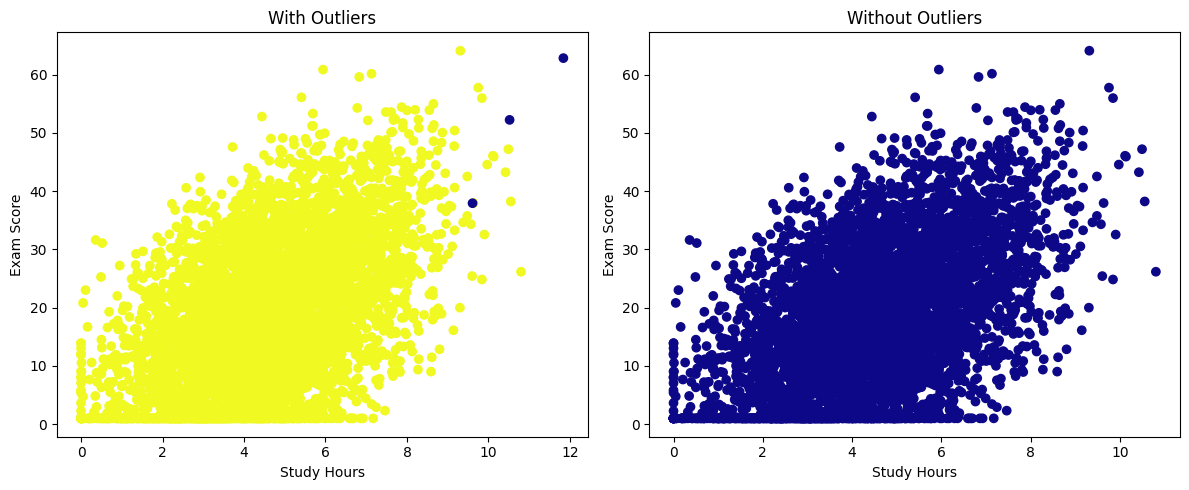

In [ ]:
# Visualization
#رسم الطلاب حسب متغيرين ساعات الدراسة مقابل درجات الطلاب)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# المخطط الأول: مع الـ Outliers
axes[0].scatter(df['study_hours'], df['exam_score'], c=df['Cluster'], cmap='plasma')
axes[0].set_xlabel("Study Hours")
axes[0].set_ylabel("Exam Score")
axes[0].set_title("With Outliers")

# المخطط الثاني: بدون الـ Outliers
axes[1].scatter(df_no_outliers['study_hours'], df_no_outliers['exam_score'], c=df_no_outliers['Cluster'], cmap='plasma')
axes[1].set_xlabel("Study Hours")
axes[1].set_ylabel("Exam Score")
axes[1].set_title("Without Outliers")

plt.tight_layout()
plt.show()

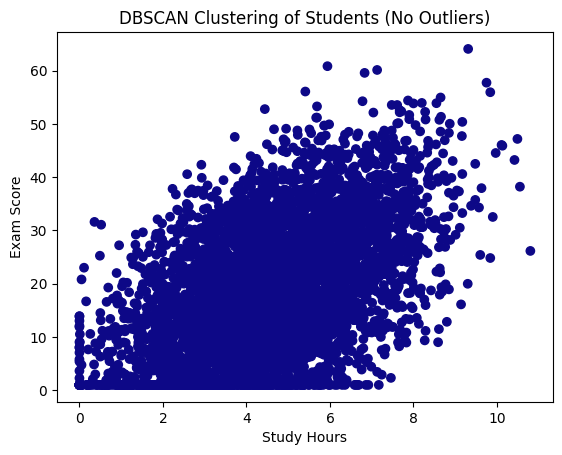

In [ ]:
# Visualization
import matplotlib.pyplot as plt

plt.scatter(df_no_outliers['study_hours'],
            df_no_outliers['exam_score'],
            c=df_no_outliers['Cluster'],
            cmap='plasma')

plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.title("DBSCAN Clustering of Students (No Outliers)")
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, labels)
print("Silhouette Score:", score)

Silhouette Score: 0.4511488630586142


## Conclusion

The DBSCAN clustering algorithm identified different student productivity patterns.

Most students belong to one main cluster representing average productivity levels, while a smaller group appears as outliers with different study behaviors.

These insights can help educators better understand student learning patterns and provide targeted academic support.

In [ ]:
# eps=1.5, min_samples=10 ممكن هاي تزبط من ناحية الاداء لطلاب
# eps=2, min_samples=20 ولكن هاي افضل في الدقة من ناحية احصائية

In [ ]:
# أظهر تطبيق خوارزمية DBSCAN
# أن معظم الطلاب ينتمون إلى نمط واحد يتميز بضعف التركيز والإنتاجية، بينما ظهر عدد قليل كحالات شاذة بأداء مرتفع وإرهاق أكبر.
# بلغت أفضل قيمة لـ Silhouette Score حوالي 0.549 عند إعدادات معينة، مما يعكس جودة متوسطة إلى جيدة للتجميع.
# تؤكد هذه النتائج أهمية الجمع بين التحليل العددي والتصور البصري للكشف عن الأنماط ودعم الطلاب تربويًا بشكل أدق
